In [1]:
# https://drive.google.com/file/d/10cyq2pvGMaHnCXR0rolTUwQ8TgsHKiEC/view?usp=sharing ?

#!gdown --id 10cyq2pvGMaHnCXR0rolTUwQ8TgsHKiEC -O vp.jpg


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib notebook

img = cv2.imread('vp.jpg')
# cv2_imshow(img)

In [3]:
def norm_points(p):
    r,c = p.shape
    for i in range(c):
        if p[-1,i] != 0:
            p[:,i] /= p[-1,i]
    return p

Definimos los puntos ideales de la reticula

In [4]:
#un cuadrado de 1x1

pr = np.ones((3,4))
#pr[:2,0] = [0., 5.]
#pr[:2,1] = [0., 0.]
#pr[:2,2] = [2.8, 0.]
#pr[:2,3] = [2.8, 5.]
pr[:2,0] = [0., 1]
pr[:2,1] = [0., 0.]
pr[:2,2] = [1, 0.]
pr[:2,3] = [1, 1.]

pr = norm_points(pr)

print("pr =\n", pr)

#Estas son las lineas de la reticula que pasan por los puntos pr.
lr = np.ones((3,4))
lr[:,0] = np.cross(pr[:,0], pr[:,1])
lr[:,1] = np.cross(pr[:,1], pr[:,2])
lr[:,2] = np.cross(pr[:,2], pr[:,3])
lr[:,3] = np.cross(pr[:,3], pr[:,0])


print("lr =\n", lr)

pr =
 [[0. 0. 1. 1.]
 [1. 0. 0. 1.]
 [1. 1. 1. 1.]]
lr =
 [[ 1.  0. -1.  0.]
 [ 0.  1.  0. -1.]
 [ 0.  0.  1.  1.]]


Definir puntos de fuga y puntos reales

In [5]:

# Definir puntos de fuga y puntos
vp1 = np.array([-3, 540, 1])
vp2 = np.array([1916, 540, 1])

p1 = np.array([114, 766, 1])
p2 = np.array([829, 677, 1])
p3 = np.array([1048, 716, 1])

blue_points = [p1, p2, p3]

# Calcular líneas
l = np.zeros((3, 4))
l[:, 0] = np.cross(vp1, p2)
l[:, 1] = np.cross(vp1, p1)
l[:, 2] = np.cross(vp2, p1)
l[:, 3] = np.cross(vp2, p3)

def norm_points(p):
    return p / p[-1]

# Calcular punto de intersección p4
p4 = np.cross(l[:, 1], l[:, 3])
p4 = norm_points(p4)

# Almacenar puntos en la matriz p
p = np.zeros((3, 4))
p[:, 0] = p1
p[:, 1] = p2
p[:, 2] = p3
p[:, 3] = p4
p = norm_points(p)

# Dibujar puntos de fuga (rojo)
cv2.circle(img, (vp1[0], vp1[1]), 5, (0, 0, 255), -1)
cv2.circle(img, (vp2[0], vp2[1]), 5, (0, 0, 255), -1)

# Dibujar puntos azules
for i, point in enumerate(blue_points):
    cv2.circle(img, (point[0], point[1]), 5, (255, 0, 0), -1)
    cv2.putText(img, f'p{i+1}', (point[0] + 10, point[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)

cv2.circle(img, (int(p4[0]), int(p4[1])), 5, (0, 255, 255), -1)  # Dibujar p4 (amarillo)
cv2.putText(img, 'p4', (int(p4[0]) + 10, int(p4[1]) - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)

# Función para calcular intersección de una línea con los bordes de la imagen
def get_line_endpoints(line, width, height):
    x0, y0, w0 = np.cross(line, [1, 0, 0])  # Intersección con x=0
    x1, y1, w1 = np.cross(line, [1, 0, -width])  # Intersección con x=width
    y0, x0 = y0 / w0, x0 / w0
    y1, x1 = y1 / w1, x1 / w1
    return (int(x0), int(y0)), (int(x1), int(y1))

# Dibujar líneas
for i in range(4):
    pt1, pt2 = get_line_endpoints(l[:, i], img.shape[1], img.shape[0])
    color = (0, 255, 0)
    cv2.line(img, pt1, pt2, color, 2)
    mid_x, mid_y = (pt1[0] + pt2[0]) // 2, (pt1[1] + pt2[1]) // 2
    cv2.putText(img, f'l{i+1}', (mid_x, mid_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)




Compute the transformation that maps the projective space into and affine one.

In [6]:
def proj2Affine(Vp1, Vp2):
  """
  This function defines a homography that maps the points that lie on the line
  defined by the homogeneous 2D points Vp1 and Vp2 to a line at the infinity

  Parameters:

  Vp1, Vp2: 3x1 matrices, that represents homogenous 2D points.

  Returns a 3x3 matrix that represents the mapping homography.

  First we compute the equation of the line where Vp1 and Vp2 lies.
  """
  m = np.array([[Vp1[0], Vp1[1]], [Vp2[0], Vp2[1]]])
  b = np.array([-1, -1])
  l = np.ones(3)
  l[:2] = np.linalg.solve(m, b)
  # Define H according to formula in Hartley & Zisserman "Multiple View Geometry"
  # 2nd edition, section 2.7.2, pp 49
  H = np.eye(3)
  H[2, :] = l.T
  return H

In [7]:
H = proj2Affine(vp1, vp2)
H

array([[ 1.        ,  0.        ,  0.        ],
       [ 0.        ,  1.        ,  0.        ],
       [ 0.        , -0.00185185,  1.        ]])

The mapping that maps lines is defined in terms of the mapping of points.


In [8]:
Hl = np.linalg.inv(H).T
Hl

array([[1.        , 0.        , 0.        ],
       [0.        , 1.        , 0.00185185],
       [0.        , 0.        , 1.        ]])

% The computed lines are mapped into the affine space.


In [9]:
lp = np.dot(Hl, l)
#lp = norm_points(lp)
print(lp.shape)
print(np.dot(lp[:,0],lp[:,1])/(np.linalg.norm(lp[:,0])*np.linalg.norm(lp[:,1])))

print(np.dot(lp[:,2],lp[:,3])/(np.linalg.norm(lp[:,2])*np.linalg.norm(lp[:,3])))


print(np.dot(lp[:,1],lp[:,2])/(np.linalg.norm(lp[:,1])*np.linalg.norm(lp[:,2])))

print(np.dot(lp[:,0],lp[:,3])/(np.linalg.norm(lp[:,0])*np.linalg.norm(lp[:,3])))

print(lp[:,0])
print(lp[:,1])
print(lp[:,2])
print(lp[:,3])

(3, 4)
0.9999947690615424
0.9999999774170448
-0.9999930040931201
-0.999999564337273
[-1.37000000e+02 -7.61111111e-01 -4.49691000e+05]
[-2.26000000e+02 -1.25555556e+00 -6.38580000e+04]
[-2.26000000e+02  8.01881481e+02  1.40609600e+06]
[-1.76000000e+02  6.24474074e+02  8.05936000e+05]


The points that intersect the lines in the affine space are compute and normalized.

In [10]:
pp = np.ones((3, 4))
pp[:, 0] = np.cross(lp[:, 1], lp[:, 2])
pp[:, 1] = np.cross(lp[:, 0], lp[:, 2])
pp[:, 2] = np.cross(lp[:, 0], lp[:, 3])
pp[:, 3] = np.cross(lp[:, 1], lp[:, 3])

pp = norm_points(pp)

pp

array([[-2.72389381e+02, -3.26755820e+03, -3.27012591e+03,
        -2.74957096e+02],
       [-1.83026549e+03, -2.67441536e+03, -2.21222660e+03,
        -1.36807673e+03],
       [ 1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00]])

<IPython.core.display.Javascript object>


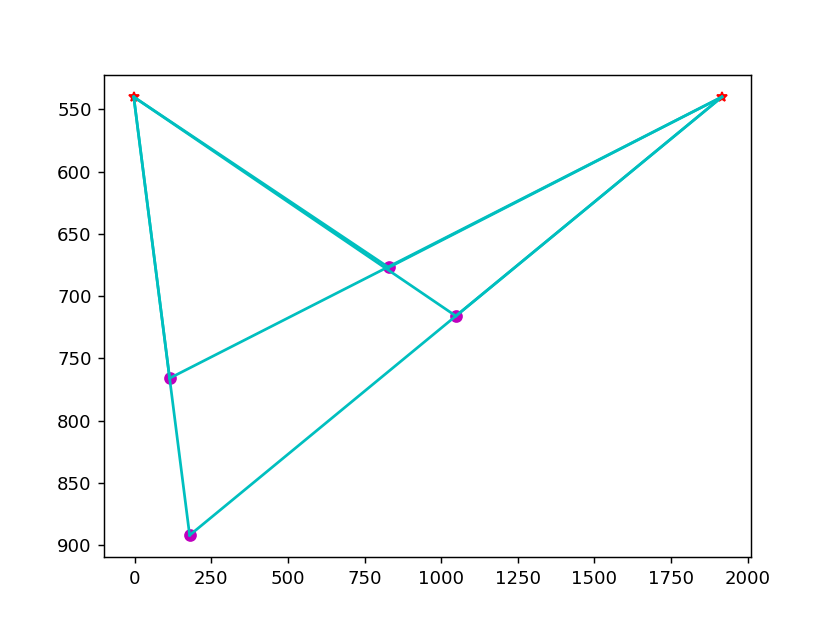

In [11]:
fig1,ax1 = plt.subplots()
ax1.plot(vp1[0],vp1[1],"r*",vp2[0],vp2[1],"r*")
ax1.plot(p[0,0],p[1,0],'om',p[0,1],p[1,1],'om',p[0,2],p[1,2],'om',p[0,3],p[1,3],'om')
ax1.plot(np.array([vp1[0], p[0,0]]), np.array([vp1[1], p[1,0]]),'c')
ax1.plot(np.array([vp1[0], p[0,1]]), np.array([vp1[1], p[1,1]]),'c')
ax1.plot(np.array([vp2[0], p[0,1]]), np.array([vp2[1], p[1,1]]),'c')
ax1.plot(np.array([vp2[0], p[0,2]]), np.array([vp2[1], p[1,2]]),'c')
ax1.plot(np.array([vp1[0], p[0,3]]), np.array([vp1[1], p[1,3]]),'c')
ax1.plot(np.array([vp1[0], p[0,2]]), np.array([vp1[1], p[1,2]]),'c')
ax1.plot(np.array([vp2[0], p[0,0]]), np.array([vp2[1], p[1,0]]),'c')
ax1.plot(np.array([vp2[0], p[0,3]]), np.array([vp2[1], p[1,3]]),'c')
ax1.invert_yaxis()

<IPython.core.display.Javascript object>


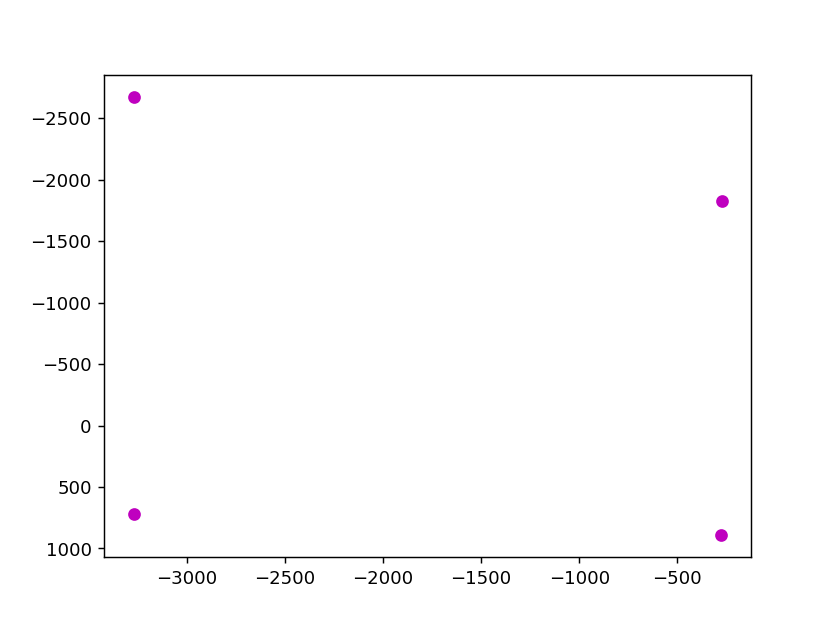

In [12]:
fig2,ax2 = plt.subplots()

ax2.plot(pp[0,0],pp[1,0],'om',pp[0,1],pp[1,1],'om',pp[0,2],p[1,2],'om',pp[0,3],p[1,3],'om')

ax2.invert_yaxis()

Homography Matrix:
[[ 1.94002150e+00 -7.60783183e+02  8.29000000e+02]
 [-1.09296703e+02 -2.18630858e+02  6.77000000e+02]
 [-2.07118300e-01 -4.01606864e-01  1.00000000e+00]]


<IPython.core.display.Javascript object>


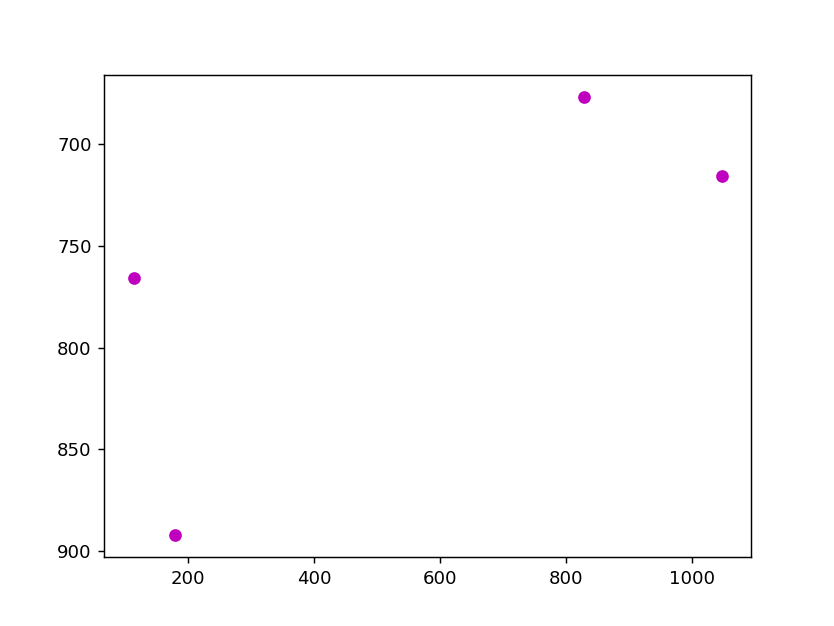

(array([[1.14000000e+02, 8.29000000e+02, 1.04800000e+03, 1.79303223e+02],
        [7.66000000e+02, 6.77000000e+02, 7.16000000e+02, 8.92141296e+02],
        [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00]]),
 array([[-1.59545099e-04,  3.36404099e-04, -2.18379637e-04,
          3.53910351e-03],
        [-1.28173872e-03, -1.88903840e-03, -1.07700858e-03,
         -1.83219034e-03],
        [ 1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
          1.00000000e+00]]))

In [13]:
# Define the source and destination points for the homography
src_pts = np.float32([pr[:, 0], pr[:, 1], pr[:, 2], pr[:, 3]])
dst_pts = np.float32([p[:, 0], p[:, 1], p[:, 2], p[:, 3]])


# Find the homography matrix
M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC)

# Print the homography matrix
print("Homography Matrix:")
print(M)

pm = np.dot(M, pr)
pm = norm_points(pm)

lm = np.dot (np.linalg.inv(M.T), lr)
lm = norm_points(lm)



fig3,ax3 = plt.subplots()

ax3.plot(pm[0,0],pm[1,0],'om',pm[0,1],pm[1,1],'om',pm[0,2],pm[1,2],'om',pm[0,3],pm[1,3],'om')

ax3.invert_yaxis()

pm,lm

In [14]:
for i in range(4):
    point = [int(np.round(pm[0,i])), int(np.round(pm[1,i]))]
    cv2.circle(img, (point[0], point[1]), 8, (255, 0, 255), -1)
    cv2.putText(img, f'p{i+1}', (point[0] + 10, point[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 255), 2)


# Mostrar la imagen
cv2.namedWindow("Ventana1", cv2.WINDOW_NORMAL)
cv2.imshow("Ventana1",img)
cv2.waitKey(0)


QSettings::value: Empty key passed
QSettings::value: Empty key passed


27

In [15]:
cv2.destroyAllWindows()

In [16]:
def def_grid_lines(r0,r1,c0,c1,w,h):
    R=np.linspace(r0,r1,r1-r0+1)
    C=np.linspace(c0,c1,c1-c0+1)
    n = len(R)+len(C)
    l=np.zeros((3, n))
    
    #Definimos primero lineas horizontales
    idx=0
    for i in R:
        l[:,idx]=[0, 1, h*i]
        idx +=1
        
    #Definimos primero lineas verticales
    for i in C:
        l[:,idx]=[1, 0, h*i]
        idx=idx+1
    return l

In [17]:
img = cv2.imread('vp.jpg')

lines = def_grid_lines(-6,6,-6,6,1,1)  # Forma (3, N_líneas)

# 4. Calcular la Homografía para Líneas (H_l)
Hl = np.linalg.inv(M).T  # M = H_p

# 5. Proyectar las Líneas a la Imagen
projected_lines = np.dot(Hl, lines)
projected_lines = projected_lines / np.linalg.norm(projected_lines, axis=0)  # Normalizar

# # Dibujar puntos proyectados
# for i in range(projected_pts.shape[1]):
#     x, y = int(projected_pts[0, i]), int(projected_pts[1, i])
#     cv2.circle(img, (x, y), 5, (0, 255, 0), -1)

# Dibujar líneas proyectadas
for i in range(projected_lines.shape[1]):
    a, b, c = projected_lines[:, i]
    # Encontrar dos puntos en la línea (para dibujar)
    x0, y0 = 0, int(-c/b) if b != 0 else 0
    x1, y1 = img.shape[1], int((-c - a*img.shape[1])/b) if b != 0 else 0
    cv2.line(img, (x0, y0), (x1, y1), (255, 0, 0), 2)

cv2.namedWindow("Projected Grid", cv2.WINDOW_NORMAL)
cv2.imshow("Projected Grid", img)
cv2.waitKey(0)
cv2.destroyAllWindows()

prolonga las lineas hasta los bordes de la imagen

In [18]:
def get_line_endpoints(line, width, height):
    x1, y1, x2, y2 = line
    line_params = np.polyfit([x1, x2], [y1, y2], 1)
    slope, intercept = line_params

    points = []
    for x in [0, width]:
        y = slope * x + intercept
        if 0 <= y <= height:
            points.append((int(x), int(y)))

    for y in [0, height]:
        x = (y - intercept) / slope
        if 0 <= x <= width:
            points.append((int(x), int(y)))

    if len(points) >= 2:
        return points[0], points[1]
    else:
        return (x1, y1), (x2, y2)

carga todas las lineas guardadas en el archivo lines_near_vps.npy

In [48]:
img = cv2.imread('vp.jpg')

lines_near_vps_no_merged = np.load('lines_near_vps.npy')
lines_near_vps = np.load('merged_lines_near_vps.npy')
print(lines_near_vps_no_merged.shape, lines_near_vps.shape)
#print(lines_near_vps)


for line in lines_near_vps_no_merged:
    x1, y1, x2, y2 = line[0]
    pt1, pt2 = get_line_endpoints((x1, y1, x2, y2), img.shape[1], img.shape[0])
    cv2.line(img, pt1, pt2, (0, 0, 255), 1)

# Iterate over each line and draw it on the image
for line in lines_near_vps:
    x1, y1, x2, y2 = line[0]

    pt1 = x1, y1
    pt2 = x2, y2
    # pt1, pt2 = get_line_endpoints((x1, y1, x2, y2), img.shape[1], img.shape[0])
    cv2.line(img, pt1, pt2, (0, 255, 0), 3)  # Green color and line thickness of 2


# Mostrar la imagen con las líneas dibujadas
cv2.namedWindow("Image with Lines", cv2.WINDOW_NORMAL)
cv2.imshow('Image with Lines', img)
cv2.waitKey(0)
cv2.destroyAllWindows()


(234, 1, 4) (16, 1, 4)


In [38]:
lines_near_vps_no_merged

array([[[ 112,  760,  830,  672]],

       [[ 291,  851,  830,  747]],

       [[ 112,  760,  830,  672]],

       [[1314,  875, 1472,  788]],

       [[ 112,  760,  830,  672]],

       [[1580,  604, 1636,  593]],

       [[ 112,  760,  830,  672]],

       [[1389,  575, 1476,  569]],

       [[ 112,  760,  830,  672]],

       [[1479,  750, 1642,  671]],

       [[ 112,  760,  830,  672]],

       [[1265,  852, 1411,  783]],

       [[ 112,  760,  830,  672]],

       [[1467,  789, 1674,  674]],

       [[ 112,  760,  830,  672]],

       [[1519,  621, 1725,  578]],

       [[ 112,  760,  830,  672]],

       [[1734,  626, 1915,  541]],

       [[ 112,  760,  830,  672]],

       [[1129,  690, 1347,  648]],

       [[ 112,  760,  830,  672]],

       [[1750,  633, 1914,  539]],

       [[ 112,  760,  830,  672]],

       [[1641,  593, 1729,  575]],

       [[ 112,  760,  830,  672]],

       [[1289,  668, 1371,  651]],

       [[ 171,  760,  829,  679]],

       [[ 521,  822,  830,  

In [44]:
cv2.destroyAllWindows()


determina si una linea pasa cerca de un VP

In [49]:
def line_passes_near_vp(line, vp, threshold=10):
    x1, y1, x2, y2 = line
    line_params = np.polyfit([x1, x2], [y1, y2], 1)
    slope, intercept = line_params
    vp_x, vp_y = vp[0], vp[1]
    return abs(vp_y - (slope * vp_x + intercept)) < threshold

separa las lienas que pasan cerca de vp1 y vp2

In [50]:
import numpy as np
import random
import cv2

In [51]:
lines_vp1 = []
lines_vp2 = []

img = cv2.imread('vp.jpg')
cv2.circle(img, (vp1[0], vp1[1]), 5, (0, 255, 0), -1)
cv2.circle(img, (vp2[0], vp2[1]), 5, (0, 255, 0), -1)

for line in lines_near_vps:
    if line_passes_near_vp(line[0], vp1):
        lines_vp1.append(line)
    elif line_passes_near_vp(line[0], vp2):
        lines_vp2.append(line)

# Draw lines passing through vp1
for line in lines_vp1:
    x1, y1, x2, y2 = line[0]
    pt1, pt2 = get_line_endpoints((x1, y1, x2, y2), img.shape[1], img.shape[0])
    cv2.line(img, pt1, pt2, (255, 0, 0), 1)  # Blue color for lines passing through vp1

# Draw lines passing through vp2
for line in lines_vp2:
    x1, y1, x2, y2 = line[0]
    pt1, pt2 = get_line_endpoints((x1, y1, x2, y2), img.shape[1], img.shape[0])
    cv2.line(img, pt1, pt2, (0, 0, 255), 1)  # Red color for lines passing through vp2

# Display the image with the drawn lines
cv2.namedWindow("Image with Lines", cv2.WINDOW_NORMAL)
cv2.imshow('Image with Lines', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [24]:
img = cv2.imread('vp.jpg')
cv2.circle(img, (vp1[0], vp1[1]), 5, (0, 255, 0), -1)
cv2.circle(img, (vp2[0], vp2[1]), 5, (0, 255, 0), -1)
# Select two random lines from lines_vp1
random_lines_vp1 = random.sample(lines_vp1, 2)
# Select two random lines from lines_vp2
random_lines_vp2 = random.sample(lines_vp2, 2)

for line in random_lines_vp1:
    x1, y1, x2, y2 = line[0]
    pt1, pt2 = get_line_endpoints((x1, y1, x2, y2), img.shape[1], img.shape[0])
    cv2.line(img, pt1, pt2, (255, 0, 0), 1)  # Blue color for lines passing through vp1
for line in random_lines_vp2:
    x1, y1, x2, y2 = line[0]
    pt1, pt2 = get_line_endpoints((x1, y1, x2, y2), img.shape[1], img.shape[0])
    cv2.line(img, pt1, pt2, (0, 0, 255), 1)  # Red color for lines passing through vp2

In [25]:
cv2.namedWindow("Image with Lines", cv2.WINDOW_NORMAL)
cv2.imshow('Image with Lines', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

automatic rankin

In [52]:
def line_similarity(line1, line2, threshold=1):
    # Normalize the lines
    line1 = line1 / np.linalg.norm(line1)
    line2 = line2 / np.linalg.norm(line2)

    distance = np.dot(line1 - line2, line1 - line2)
    print('distance = ', distance)

    # Compute similarity
    return distance < threshold * threshold

In [53]:
def points_to_homogeneous_line(x1, y1, x2, y2):
    return np.cross([x1, y1, 1], [x2, y2, 1])

In [54]:
def order_lines_by_intersection(lines, horizon_y=540, offset=10):
    H10 = np.array([0, 1, -(horizon_y + offset)])  # Línea horizontal

    intersections = []
    for line in lines:
        intersection = np.cross(line, H10)
        intersection = intersection / intersection[-1]  # Normalizar
        intersections.append(intersection)

    # Ordenar las líneas según la coordenada x de las intersecciones
    sorted_indices = np.argsort([pt[0] for pt in intersections])  # Ordenar por x
    ordered_lines = [lines[i] for i in sorted_indices]
    return ordered_lines

In [55]:
def main_process(lines_near_vps, vp1, vp2, iterations=100, grid_size=5):
    results = []

    for _ in range(iterations):
        # Step 1: Select random lines
        random_lines_vp1 = random.sample(lines_vp1, 2)
        random_lines_vp2 = random.sample(lines_vp2, 2)
        homogeneous_lines = [points_to_homogeneous_line(*line[0]) for line in random_lines_vp1 + random_lines_vp2]
        # print(homogeneous_lines)

        ordered_lines = order_lines_by_intersection(homogeneous_lines)

        # Step 2: Find intersections
        l1 = ordered_lines[1]
        l2 = ordered_lines[0]
        l3 = ordered_lines[2]
        l4 = ordered_lines[3]

        p1 = np.cross(l2, l3)
        p2 = np.cross(l1, l3)
        p3 = np.cross(l1, l4)
        p4 = np.cross(l2, l4)

        p = np.zeros((3, 4))
        p[:, 0] = p1
        p[:, 1] = p2
        p[:, 2] = p3
        p[:, 3] = p4
        p = norm_points(p)

        # Define the square of 1x1
        pr = np.ones((3,4))
        pr[:2,0] = [0., 1]
        pr[:2,1] = [0., 0.]
        pr[:2,2] = [1, 0.]
        pr[:2,3] = [1, 1.]
        pr = norm_points(pr)

        # Compute homography M

        src_pts = np.float32([pr[:, 0], pr[:, 1], pr[:, 2], pr[:, 3]])
        dst_pts = np.float32([p[:, 0], p[:, 1], p[:, 2], p[:, 3]])
        M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC)


        # Step 3: Project grid
        grid_lines = def_grid_lines(-grid_size, grid_size, -grid_size, grid_size, 1, 1)

        try:
            Hl = np.linalg.inv(M).T
        except np.linalg.LinAlgError:
            continue

        projected_lines = np.dot(Hl, grid_lines)
        projected_lines = projected_lines / np.linalg.norm(projected_lines, axis=0)

        # Step 4: Compare lines
        similarities = 0
        for line in projected_lines.T:
            for original_line in lines_near_vps:
                original_line =original_line[0]
                homogeneous_line = points_to_homogeneous_line(original_line[0], original_line[1], original_line[2], original_line[3])

                if line_similarity(line, homogeneous_line):
                    similarities += 1
                    break

        # Step 5: Save results
        results.append((similarities, M))

    # Step 6: Rank results
    results.sort(key=lambda x: x[0], reverse=True)
    return results

In [56]:
# Load data
lines_near_vps = np.load('merged_lines_near_vps.npy')
vp1 = np.array([-3, 540, 1])
vp2 = np.array([1916, 540, 1])

In [57]:
# Run the process
best_results = main_process(lines_near_vps, vp1, vp2, iterations=100, grid_size=5)

distance =  3.9999996738137344
distance =  3.999999657602023
distance =  3.9999983939199137
distance =  3.999999866842185
distance =  3.999998566016813
distance =  3.999998575583869
distance =  3.9999993530904208
distance =  3.9999983611276346
distance =  3.9999993764332924
distance =  3.999999658696237
distance =  3.999999799791407
distance =  3.9999998571666766
distance =  3.9999999219323077
distance =  3.999999902196456
distance =  3.9999999953521432
distance =  3.9999999228097494
distance =  3.9999996755233496
distance =  3.999999659370508
distance =  3.999998397976677
distance =  3.999999867869342
distance =  3.9999985698151015
distance =  3.9999985793891053
distance =  3.9999993556026454
distance =  3.9999983652364244
distance =  3.999999378833783
distance =  3.9999996604192303
distance =  3.9999998010674758
distance =  3.9999998582027234
distance =  3.999999918587921
distance =  3.9999998984573053
distance =  3.9999999945095968
distance =  3.999999919493702
distance =  3.9999996

distance =  3.9999999269473014
distance =  3.9999992292246556
distance =  3.9999992043501407
distance =  3.9999975217575994
distance =  3.999999548893048
distance =  3.999997736817793
distance =  3.999997748766781
distance =  3.999998765211577
distance =  3.9999974810294487
distance =  3.9999987978031113
distance =  3.9999992062071814
distance =  3.999999431267057
distance =  3.999999531395123
distance =  3.9999998854151646
distance =  3.999999872298961
distance =  3.9999999148999583
distance =  3.9999998978697207
distance =  3.9999988028840674
distance =  3.999998771933907
distance =  3.9999967943486134
distance =  3.9999992117509544
distance =  3.9999970396124374
distance =  3.9999970532813043
distance =  3.999998238010101
distance =  3.999996748050594
distance =  3.999998276983971
distance =  3.9999987742400354
distance =  3.999999058452066
distance =  3.9999991886724238
distance =  3.99999974041329
distance =  3.9999997311941655
distance =  3.999999743780875
distance =  3.999999761

distance =  3.999997242841035
distance =  3.999997195966357
distance =  3.999994445621093
distance =  3.999997885364312
distance =  3.9999947700242013
distance =  3.9999947881831965
distance =  3.9999964137377093
distance =  3.9999943847256825
distance =  3.9999964694774346
distance =  3.999997199480475
distance =  3.9999976386379457
distance =  3.9999978476927303
distance =  3.9999989195201957
distance =  3.999998920783737
distance =  3.9999988527437247
distance =  3.9999989621200864
distance =  3.999395152381966
distance =  3.999394460975836
distance =  3.9993604209097597
distance =  3.9994052561224276
distance =  3.9993639491659314
distance =  3.999364149597995
distance =  3.9993836248358363
distance =  3.999359769157566
distance =  3.9993843580162367
distance =  3.9993945124410817
distance =  3.9994012257768987
distance =  3.999404626774255
distance =  3.9994266924053288
distance =  3.99942710978625
distance =  3.9994238380177802
distance =  3.9994276197504157
distance =  3.9244318

In [58]:

# Print the top 5 results
for i, (similarities, M) in enumerate(best_results[:5]):
    print(f"Rank {i+1}: Similarities = {similarities}")
    print("Matrix M:")
    print(M)

Rank 1: Similarities = 22
Matrix M:
[[ 1.51773488e+02 -6.28654934e+01  9.19230774e+02]
 [-1.95813841e+01 -1.81278308e+01  6.60853821e+02]
 [-7.58916301e-02 -3.33731179e-02  1.00000000e+00]]
Rank 2: Similarities = 22
Matrix M:
[[ 1.15143925e+02 -5.82425162e+01  7.73333313e+02]
 [-1.48507097e+01 -1.58327892e+01  6.40719971e+02]
 [-5.75666703e-02 -2.95196287e-02  1.00000000e+00]]
Rank 3: Similarities = 22
Matrix M:
[[ 1.79651623e+02 -5.57000136e+01  6.57004822e+02]
 [-2.31772416e+01 -1.53598965e+01  6.24666687e+02]
 [-8.98298133e-02 -2.86614455e-02  1.00000000e+00]]
Rank 4: Similarities = 22
Matrix M:
[[-4.09278940e-04 -1.68826166e+02  1.47299512e+03]
 [-1.89420262e+01 -4.81361247e+01  7.47692322e+02]
 [-3.50777364e-02 -8.85308390e-02  1.00000000e+00]]
Rank 5: Similarities = 22
Matrix M:
[[ 8.07307186e+00 -2.37462552e+02  1.49013159e+03]
 [-1.39806835e+01 -6.77065378e+01  7.39638184e+02]
 [-2.82672553e-02 -1.24523554e-01  1.00000000e+00]]


In [ ]:
for i, (similarities, M) in enumerate(best_results[:5]):
    img = cv2.imread('vp.jpg')
    lines = def_grid_lines(-5,5,-5,5,1,1)
    Hl = np.linalg.inv(M).T
    projected_lines = np.dot(Hl, lines)
    projected_lines = projected_lines / np.linalg.norm(projected_lines, axis=0)
    # Dibujar líneas proyectadas
    for i in range(projected_lines.shape[1]):
        a, b, c = projected_lines[:, i]
        # Encontrar dos puntos en la línea (para dibujar)
        x0, y0 = 0, int(-c/b) if b != 0 else 0
        x1, y1 = img.shape[1], int((-c - a*img.shape[1])/b) if b != 0 else 0
        cv2.line(img, (x0, y0), (x1, y1), (255, 0, 0), 2)

    cv2.namedWindow("Projected Grid", cv2.WINDOW_NORMAL)
    cv2.imshow("Projected Grid", img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()